# A Predictive Model for US Airline Flight Delays - Flight Data Preprocessing EDA

### <span style="color:chocolate"> Project Description </span>

Flight delay prediction is an important research field, as flight delays are the primary concern of aviation
stakeholders. Our project aims to identify the predictors of flight delays before they happen, improve
travelers experience, and help airlines shift from reactive damage control to proactive delay management.

---
### <span style="color:chocolate">Import libraries</span>

In [1]:
import numpy as np
import pandas as pd
import glob
import os
from matplotlib import pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

---
### <span style="color:chocolate">Data Ingestion</span>

Reading the data from 2022 to 2026 to the data frame downloaded from the following data sources:
- Flight data: Bureau of transportation stats https://www.transtats.bts.gov/ontime/

In [2]:
# Read in the SFO B6 HA UA WN flights data to the data frame.
flights = pd.read_csv('Data/Departures_consolidated_B6_HA_UA_WN.csv', sep=',')

---
#### <span style="color:chocolate">Data Preprocessing</span>



In [3]:
# Print out the shape and data type of the flights data frame.
print('The shape of the flights data frame:', flights.shape)
print('')
print('The data type of the flights data frame:', flights.dtypes)

The shape of the flights data frame: (279101, 17)

The data type of the flights data frame: Carrier Code                                object
Date (MM/DD/YYYY)                           object
Flight Number                                int64
Tail Number                                 object
Destination Airport                         object
Scheduled departure time                    object
Actual departure time                       object
Scheduled elapsed time (Minutes)             int64
Actual elapsed time (Minutes)                int64
Departure delay (Minutes)                    int64
Wheels-off time                             object
Taxi-Out time (Minutes)                      int64
Delay Carrier (Minutes)                      int64
Delay Weather (Minutes)                      int64
Delay National Aviation System (Minutes)     int64
Delay Security (Minutes)                     int64
Delay Late Aircraft Arrival (Minutes)        int64
dtype: object


In [4]:
flights.head()

,Carrier Code,Date (MM/DD/YYYY),Flight Number,Tail Number,Destination Airport,Scheduled departure time,Actual departure time,Scheduled elapsed time (Minutes),Actual elapsed time (Minutes),Departure delay (Minutes),Wheels-off time,Taxi-Out time (Minutes),Delay Carrier (Minutes),Delay Weather (Minutes),Delay National Aviation System (Minutes),Delay Security (Minutes),Delay Late Aircraft Arrival (Minutes)
0,B6,01/01/2022,16,N947JB,JFK,07:00,06:54,324,311,-6,07:05,11,0,0,0,0,0
1,B6,01/01/2022,278,N986JB,FLL,23:27,23:26,320,300,-1,23:38,12,0,0,0,0,0
2,B6,01/01/2022,434,N990JL,BOS,07:25,07:29,326,305,4,07:41,12,0,0,0,0,0
3,B6,01/01/2022,482,N652JB,EWR,21:57,00:47,321,324,170,01:03,16,0,0,3,0,170
4,B6,01/01/2022,534,N968JT,BOS,15:00,14:57,335,306,-3,15:10,13,0,0,0,0,0


In [5]:
# Change the columns names to lower cases and replace the space with underline.
flights.columns = flights.columns.str.strip().str.lower().str.replace(" " , "_")

In [8]:
#Convert DATE column to datatime object without append the time.
flights['date_(mm/dd/yyyy)'] = pd.to_datetime(flights['date_(mm/dd/yyyy)'])

#Convert the tail number and destination airport columns to string.
flights['tail_number'] = flights['tail_number'].astype('string')
flights['destination_airport'] = flights['destination_airport'].astype('string')

#Convert the columns that contain time only to time object.
flights['scheduled_departure_time'] = pd.to_datetime(flights['scheduled_departure_time'], format='mixed', errors='coerce').dt.time
flights['actual_departure_time'] = pd.to_datetime(flights['actual_departure_time'], format='mixed', errors='coerce').dt.time

#Convert the columns that contain time duration to timedelta64 object.
duration_columns = ['scheduled_elapsed_time_(minutes)', 'actual_elapsed_time_(minutes)', 'departure_delay_(minutes)', 'taxi-out_time_(minutes)', 'delay_carrier_(minutes)', 'delay_weather_(minutes)', 'delay_national_aviation_system_(minutes)', 'delay_security_(minutes)', 'delay_late_aircraft_arrival_(minutes)']

flights[duration_columns] = flights[duration_columns].apply(lambda col: pd.to_timedelta(col))

In [9]:
# Check the types of each column in the data frame again.
print('The data type of the flights data frame:', flights.dtypes)

The data type of the flights data frame: carrier_code                                         object
date_(mm/dd/yyyy)                            datetime64[ns]
flight_number                                         int64
tail_number                                  string[python]
destination_airport                          string[python]
scheduled_departure_time                     datetime64[ns]
actual_departure_time                        datetime64[ns]
scheduled_elapsed_time_(minutes)            timedelta64[ns]
actual_elapsed_time_(minutes)               timedelta64[ns]
departure_delay_(minutes)                   timedelta64[ns]
wheels-off_time                                      object
taxi-out_time_(minutes)                     timedelta64[ns]
delay_carrier_(minutes)                     timedelta64[ns]
delay_weather_(minutes)                     timedelta64[ns]
delay_national_aviation_system_(minutes)    timedelta64[ns]
delay_security_(minutes)                    timedelta64[ns]

In [10]:
flights.head()

,carrier_code,date_(mm/dd/yyyy),flight_number,tail_number,destination_airport,scheduled_departure_time,actual_departure_time,scheduled_elapsed_time_(minutes),actual_elapsed_time_(minutes),departure_delay_(minutes),wheels-off_time,taxi-out_time_(minutes),delay_carrier_(minutes),delay_weather_(minutes),delay_national_aviation_system_(minutes),delay_security_(minutes),delay_late_aircraft_arrival_(minutes)
0,B6,2022-01-01,16,N947JB,JFK,NaT,NaT,0 days 00:00:00.000000324,0 days 00:00:00.000000311,-1 days +23:59:59.999999994,07:05,0 days 00:00:00.000000011,0 days,0 days,0 days 00:00:00,0 days,0 days 00:00:00
1,B6,2022-01-01,278,N986JB,FLL,NaT,NaT,0 days 00:00:00.000000320,0 days 00:00:00.000000300,-1 days +23:59:59.999999999,23:38,0 days 00:00:00.000000012,0 days,0 days,0 days 00:00:00,0 days,0 days 00:00:00
2,B6,2022-01-01,434,N990JL,BOS,NaT,NaT,0 days 00:00:00.000000326,0 days 00:00:00.000000305,0 days 00:00:00.000000004,07:41,0 days 00:00:00.000000012,0 days,0 days,0 days 00:00:00,0 days,0 days 00:00:00
3,B6,2022-01-01,482,N652JB,EWR,NaT,NaT,0 days 00:00:00.000000321,0 days 00:00:00.000000324,0 days 00:00:00.000000170,01:03,0 days 00:00:00.000000016,0 days,0 days,0 days 00:00:00.000000003,0 days,0 days 00:00:00.000000170
4,B6,2022-01-01,534,N968JT,BOS,NaT,NaT,0 days 00:00:00.000000335,0 days 00:00:00.000000306,-1 days +23:59:59.999999997,15:10,0 days 00:00:00.000000013,0 days,0 days,0 days 00:00:00,0 days,0 days 00:00:00


---
#### <span style="color:chocolate">Data Exploratory</span>

Create a scatterplot matrix to visualize the pair-wise correlations between different features and outcome in the (X_train_std, Y_train_std) data.

In [11]:
# Check if there is any null values in the dataframe
flights.isnull().any()

carrier_code                                False
date_(mm/dd/yyyy)                           False
flight_number                               False
tail_number                                  True
destination_airport                         False
scheduled_departure_time                     True
actual_departure_time                        True
scheduled_elapsed_time_(minutes)            False
actual_elapsed_time_(minutes)               False
departure_delay_(minutes)                   False
wheels-off_time                             False
taxi-out_time_(minutes)                     False
delay_carrier_(minutes)                     False
delay_weather_(minutes)                     False
delay_national_aviation_system_(minutes)    False
delay_security_(minutes)                    False
delay_late_aircraft_arrival_(minutes)       False
dtype: bool

In [13]:
# Calculate the total number of missing value in each column.
tail_num = flights['tail_number'].isna().sum()
scheduled_dep = flights['scheduled_departure_time'].isna().sum()
actual_dep = flights['actual_departure_time'].isna().sum()

print("Missing tail number value:", tail_num)
print("Missing scheduled departure time:", scheduled_dep)
print("Missing actual departure time:", actual_dep)

Missing tail number value: 2211
Missing scheduled departure time: 279101
Missing actual departure time: 279101


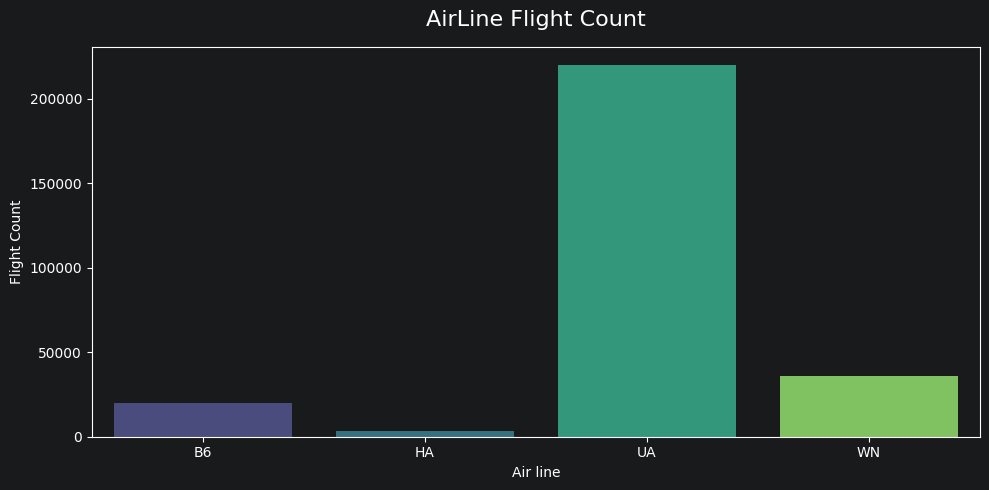

In [14]:
# Set up the matplotlib figure
plt.figure(figsize=(10, 5))

# Plot the flight count histogram
sns.countplot(data=flights, x='carrier_code', hue='carrier_code', palette='viridis', color='gold')
plt.title('AirLine Flight Count', fontsize=16, pad=15)
plt.xlabel('Air line', fontsize=10)
plt.ylabel('Flight Count', fontsize=10)

# Adjust padding parameters of the subplot and display the plots.
plt.tight_layout()
plt.show()

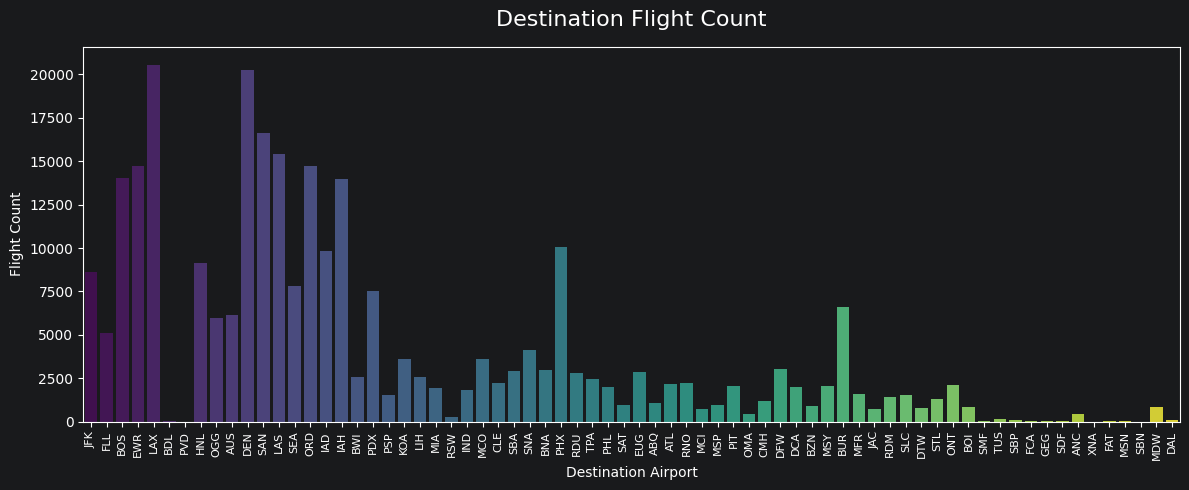

In [15]:
# Set up the matplotlib figure
plt.figure(figsize=(12, 5))  # Slightly widened to give bars more breathing room

# Create a histogram for destination count
sns.countplot(data=flights, x='destination_airport', hue='destination_airport', palette='viridis')
plt.title('Destination Flight Count', fontsize=16, pad=15)
# Rotate the x label to 90 degrees with center alignment
plt.xticks(rotation=90, ha='center', fontsize=8)
# Label x and y axes.
plt.xlabel('Destination Airport', fontsize=10)
plt.ylabel('Flight Count', fontsize=10)
# Display the histogram
plt.tight_layout()
plt.show()

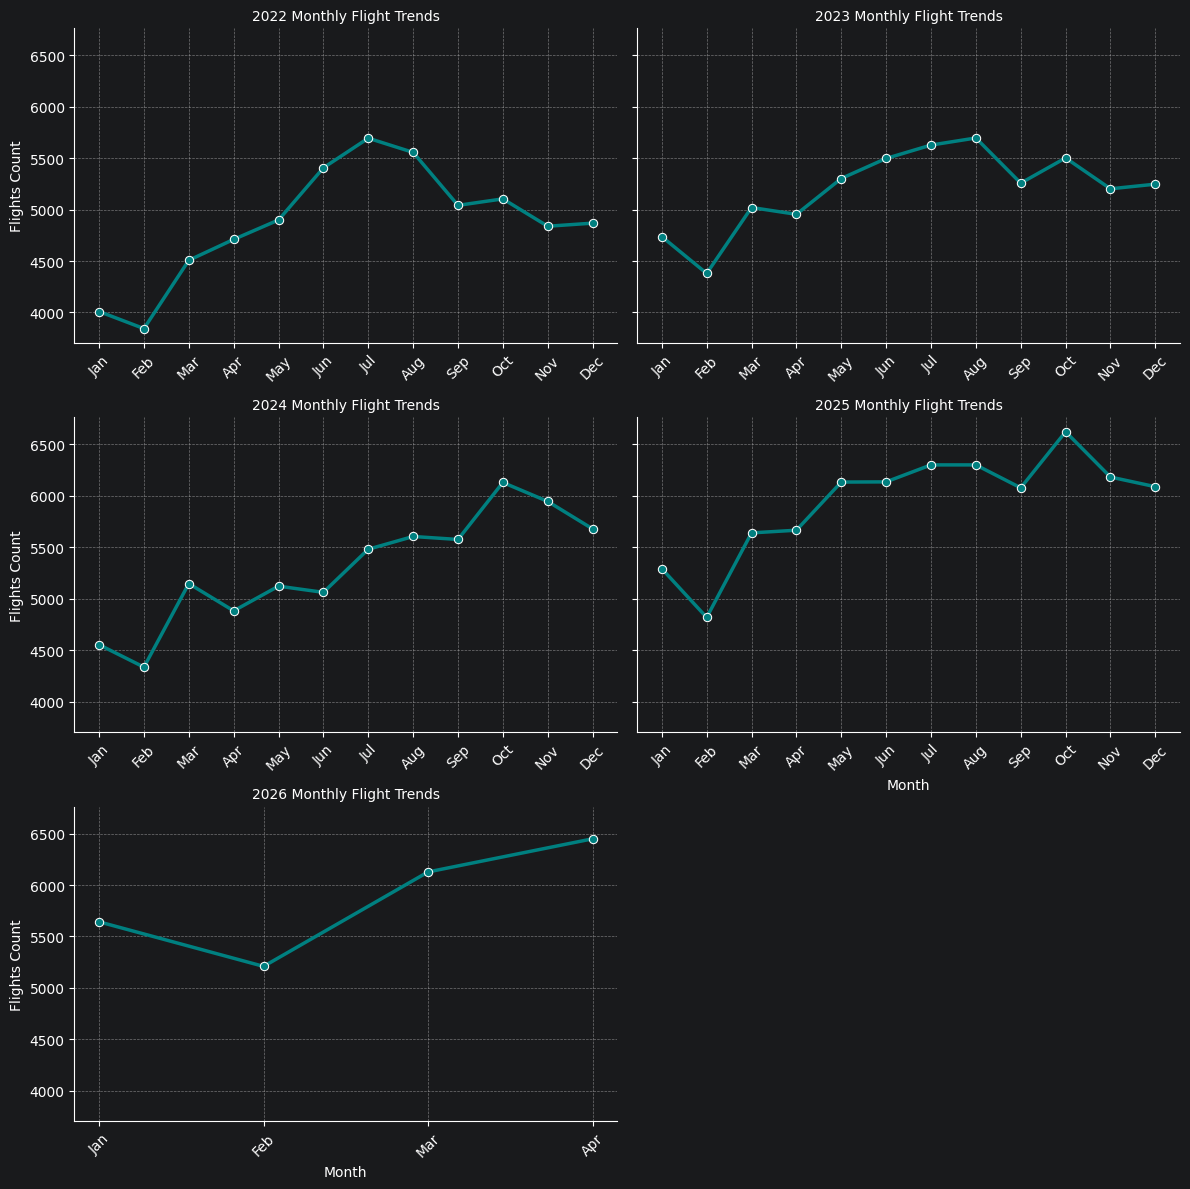

In [16]:
# Extract Year and Month
flights["Year"] = flights["date_(mm/dd/yyyy)"].dt.year
flights["Month"] = flights["date_(mm/dd/yyyy)"].dt.month
flights["Month_Name"] = flights["date_(mm/dd/yyyy)"].dt.strftime("%b")

# Group the data to count flights for each month in each year
monthly_counts = (
    flights.groupby(["Year", "Month", "Month_Name"])
    .size()
    .reset_index(name="Flight_Count")
)

# Create the chart
g = sns.relplot(
    data=monthly_counts,
    x="Month_Name",
    y="Flight_Count",
    col="Year",
    col_wrap=2,
    kind="line",
    marker="o",
    linewidth=2.5,
    color="teal",
    height=4,
    aspect=1.5,
    facet_kws=dict(sharex=False),
)

# Label and configure the chart
g.set_titles("{col_name} Monthly Flight Trends")
g.set_axis_labels("Month", "Flights Count")
for ax in g.axes.flat:
    ax.tick_params(axis="x", labelbottom=True, labelrotation=45)
    ax.grid(True, linestyle="--", alpha=0.6)

# Plot the chart
plt.tight_layout()
plt.show()

---
#### <span style="color:chocolate">Data splits</span>

Partition the data into training, validation, and test sets using a splitting rule of [60%, 20%, 20%] in chronological order. Name the resulting dataframes as follows:
- train
- val
- test

In [17]:
# Sort the data in the flight dataframe by date.
flights = flights.sort_values('date_(mm/dd/yyyy)').reset_index(drop=True)

In [18]:
# Calculate the number of samples based on the split percentage then save the indexes number.
total_rows = len(flights)
train_end_idx = int(total_rows * 0.60)
test_end_idx = train_end_idx + int(total_rows * 0.20)

# Split the data
train = flights.iloc[:train_end_idx]
test = flights.iloc[train_end_idx:test_end_idx]
val = flights.iloc[test_end_idx:]

In [19]:
# Verify the date range is split correctly
print(f"Train: {train['date_(mm/dd/yyyy)'].min()} to {train['date_(mm/dd/yyyy)'].max()}")
print(f"Test: {test['date_(mm/dd/yyyy)'].min()} to {test['date_(mm/dd/yyyy)'].max()}")
print(f"Val: {val['date_(mm/dd/yyyy)'].min()} to {val['date_(mm/dd/yyyy)'].max()}")

Train: 2022-01-01 00:00:00 to 2024-10-05 00:00:00
Test: 2024-10-05 00:00:00 to 2025-07-26 00:00:00
Val: 2025-07-26 00:00:00 to 2026-04-30 00:00:00


---
#### <span style="color:chocolate">Data Exploratory Data Analysis (EDA)</span>

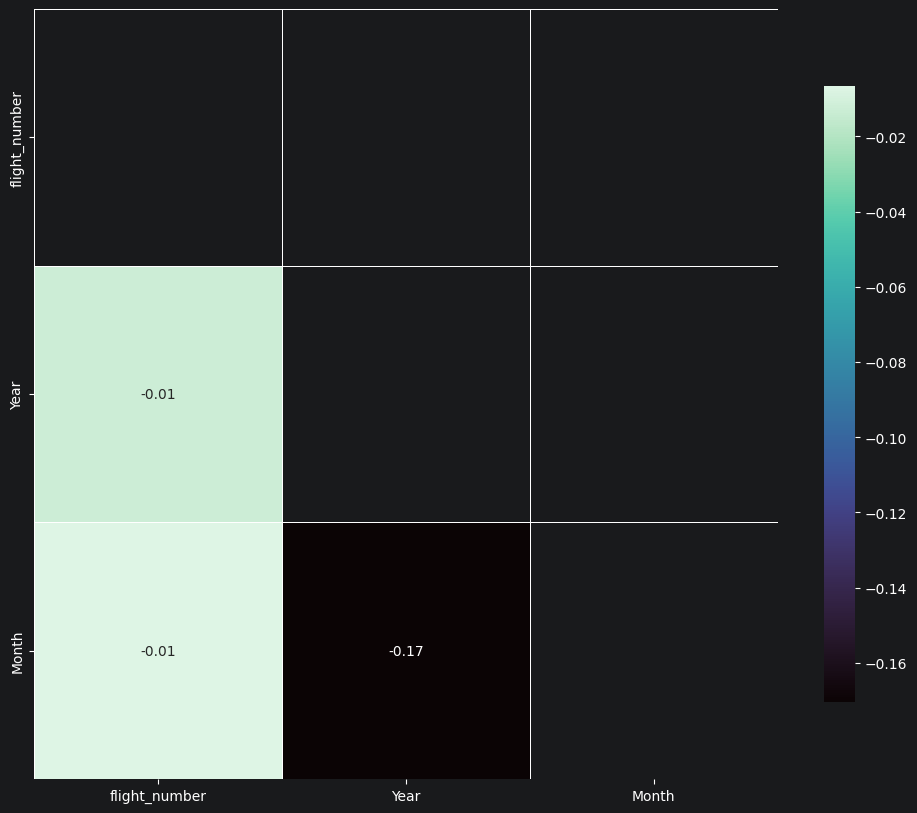

In [20]:
# Pick out the numerical data column for analysis
timedelta_cols = [
    'scheduled_elapsed_time_(minutes)', 'actual_elapsed_time_(minutes)',
    'departure_delay_(minutes)', 'taxi-out_time_(minutes)',
    'delay_carrier_(minutes)', 'delay_weather_(minutes)',
    'delay_national_aviation_system_(minutes)', 'delay_security_(minutes)',
    'delay_late_aircraft_arrival_(minutes)'
]
# Create the correlation matrix
correlation_matrix = train.corr(numeric_only=True)
# Create a mask to filter out the repeated output.
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

# Set up the matplotlib
plt.figure(figsize=(12, 10))

# Configure the correlation matrix
sns.heatmap(
    correlation_matrix,
    mask=mask,
    annot=True,
    cmap='mako',
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.show()

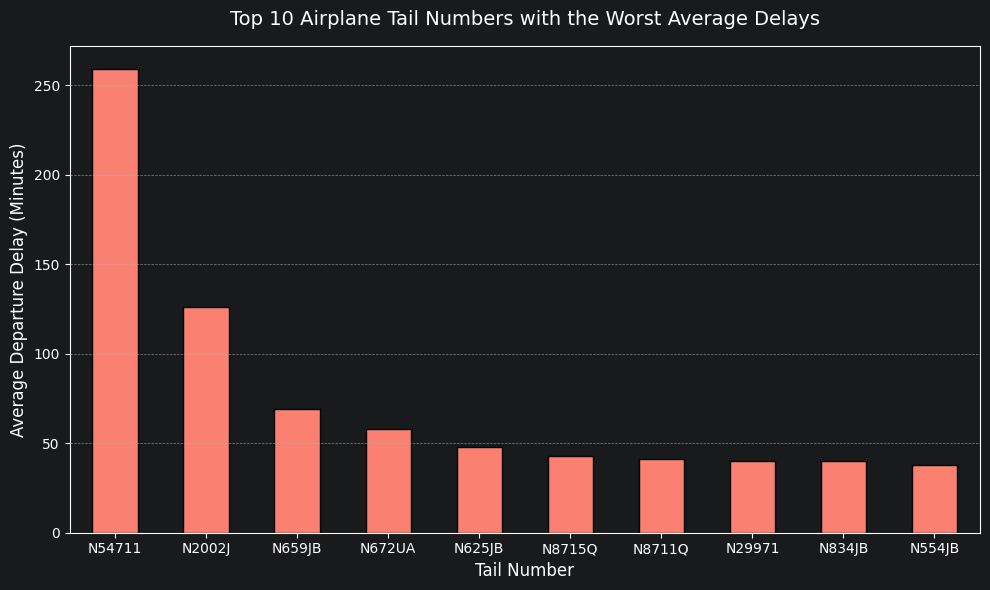

In [21]:
# Get the flight counts based on tail number.
flight_counts = train['tail_number'].value_counts()

# Calculate the average delay by tail number then only select the top 10.
top_delayed_tail_num = (
    train.groupby('tail_number')['delay_late_aircraft_arrival_(minutes)']
    .mean()
    .nlargest(10)
)

# Plot the chart
plt.figure(figsize=(10, 6))

# Add labels and Configure the chart
top_delayed_tail_num.plot(kind='bar', color='salmon', edgecolor='black')
plt.title('Top 10 Airplane Tail Numbers with the Worst Average Delays', fontsize=14, pad=15)
plt.ylabel('Average Departure Delay (Minutes)', fontsize=12)
plt.xlabel('Tail Number', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Display the plot
plt.tight_layout()
plt.show()

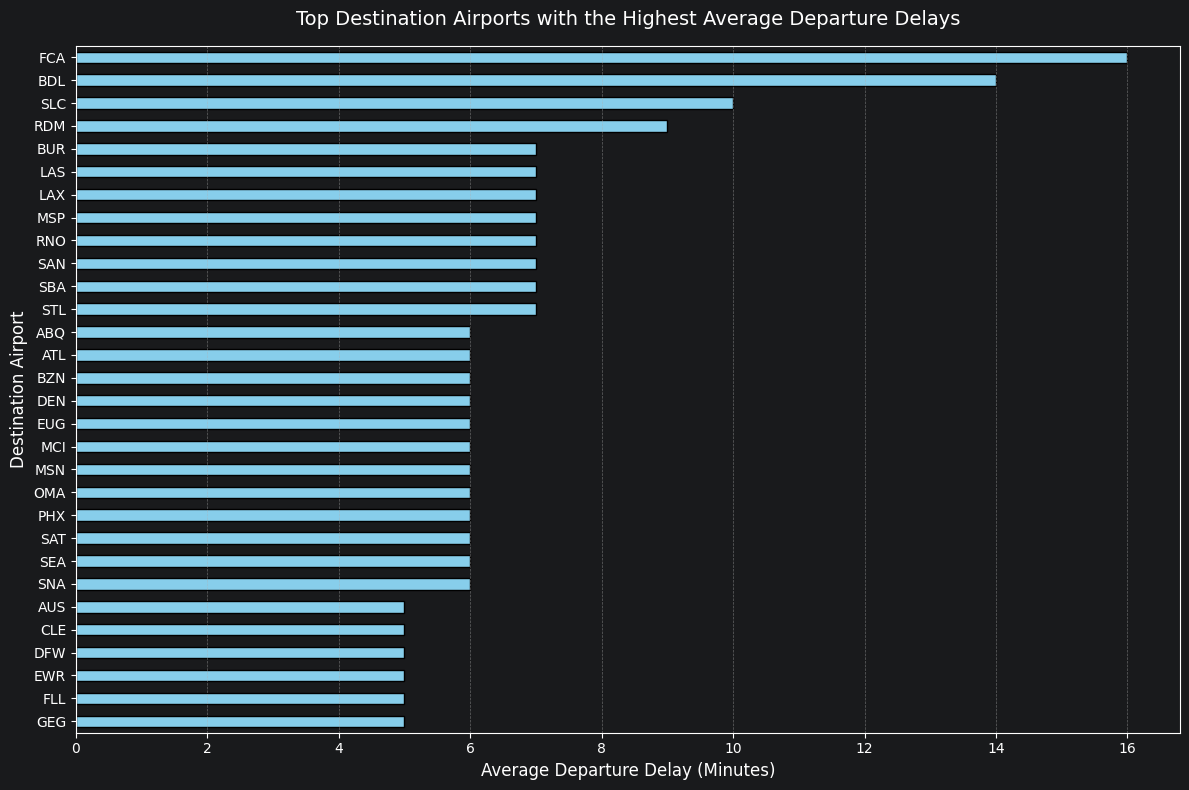

In [22]:
# Calculate average delay for each destination and select the top 30 to include in the chart
top_delayed_airports = (
    train.groupby('destination_airport')['delay_late_aircraft_arrival_(minutes)']
    .mean()
    .nlargest(30)
)

# Plot the chart
plt.figure(figsize=(12, 8))

# Add labels and Configure the chart
top_delayed_airports.plot(kind='barh', color='skyblue', edgecolor='black')
plt.title('Top Destination Airports with the Highest Average Departure Delays', fontsize=14, pad=15)
plt.xlabel('Average Departure Delay (Minutes)', fontsize=12)
plt.ylabel('Destination Airport', fontsize=12)
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Display the plot
plt.tight_layout()
plt.show()